# Notebook 014 — Port the Daily Market-Regime Engine, and Score Its Accuracy


In [1]:
import sys

sys.path.insert(0, "..")
sys.path.insert(0, "tmp")
import json

TMP = "tmp"

def load(name):
    with open(f"{TMP}/{name}") as f:
        return json.load(f)

prereg = load("phase_0_14_preregistration.json")
print("Gates pre-registered:", list(prereg["gates"].keys()))
print("Episode table entries:", len(prereg["episode_table"]))
print("Holdouts untouched:", prereg["scope"]["holdouts_untouched"])


Gates pre-registered: ['NL', 'RA', 'RM', 'RL', 'RS', 'RC']
Episode table entries: 8
Holdouts untouched: {'crypto': '2025-07-01', 'futures': '2025-01-01 to 2026-07-28'}


## Phase 0 — Ground truth, port verification, pre-registration

`src/regime/` is a module-for-module port of `../ultron/libs/finance/src/ultron_finance/regime/`
(engine) and `../ultron/apps/trading-labs/common/regime_report/` (report layer), rewired onto this
repo's parquet data via `src/regime/loaders.py`. Before any scoring runs, this phase verifies three
things: every data source NEXT_PROMPT.md sec3 claims exists actually does (with row counts and date
ranges), the port reproduces the source engine's scores where both can be executed, and the ported
`no_lookahead_check` passes as a **hard gate** on every symbol in the universe. All three, plus the
frozen episode table and gate definitions, are committed to `phase_0_14_preregistration.json`
before Phase 1 ever builds or plots the historical panel.


In [2]:
intro = prereg["ground_truth_phase0_findings"]
print(f"Bars: {len(intro['bars'])} symbols")
for sym in sorted(intro["bars"]):
    row = intro["bars"][sym]
    print(f"  {sym:8s} {row['rows']:6d} rows  {row['first']} -> {row['last']}")
print(f"\nFRED: {len(intro['fred'])} series")
for series in intro["fred"]:
    row = intro["fred"][series]
    print(f"  {series:14s} {row['rows']:6d} rows  {row['first']} -> {row['last']}")
print(f"\nCOT: {intro['cot']}")
print(f"\nCurves: {len(intro['curves'])} symbols")
for sym in intro["curves"]:
    row = intro["curves"][sym]
    print(f"  {sym:8s} {row['rows']:6d} rows  {row['first']} -> {row['last']}")


Bars: 27 symbols
  6A=F       6436 rows  2000-11-08 -> 2026-07-31
  6B=F       6447 rows  2000-10-05 -> 2026-07-31
  6C=F       6553 rows  2000-05-23 -> 2026-07-31
  6E=F       6533 rows  2000-09-12 -> 2026-07-31
  6J=F       6456 rows  2000-09-13 -> 2026-07-31
  6S=F       6441 rows  2000-11-10 -> 2026-07-31
  BZ=F       4730 rows  2007-07-30 -> 2026-07-31
  CL=F       6512 rows  2000-08-23 -> 2026-07-31
  CT=F       6664 rows  2000-01-03 -> 2026-07-30
  ES=F       6531 rows  2000-09-18 -> 2026-07-31
  GC=F       6503 rows  2000-08-30 -> 2026-07-31
  HE=F       6437 rows  2000-12-15 -> 2026-07-30
  HG=F       6508 rows  2000-08-30 -> 2026-07-31
  HO=F       6506 rows  2000-09-01 -> 2026-07-31
  KC=F       6662 rows  2000-01-03 -> 2026-07-30
  LE=F       6369 rows  2001-03-01 -> 2026-07-30
  NG=F       6509 rows  2000-08-30 -> 2026-07-31
  PA=F       6543 rows  1998-09-28 -> 2026-07-31
  PL=F       6532 rows  1997-10-29 -> 2026-07-31
  RB=F       6467 rows  2000-11-01 -> 2026-07-31
  S

In [3]:
print("Disclosed gaps:")
for gap in intro["disclosed_gaps"]:
    print(f"- {gap}")


Disclosed gaps:
- COT: only 067651 (CRUDE OIL, LIGHT SWEET) present; macro sector's cot_market ('E-MINI S&P 500') has no series in this repo -- macro sector cot input is always None (see regime/builder.py docstring).
- Curves: only 5 of 20 Commodities-basket symbols have a curve file (CL, NG, GC, SI, HG); the other 15 legs are permanently curve=None, so term_structure/carry for the Commodities basket are always a 5-symbol aggregate, never 20.
- Curves start 2018-01-02 while bars start as early as 2000 for some symbols; term_structure/carry are NaN for all curve symbols before their curve's start date.
- curve_slope is called with far='close_f3' (regime/dimensions/term_structure.py), not production's far='close_f12' default -- this repo's curves have only 3 legs, so term_structure/carry are scored on a 3-month slope, not a 12-month slope.


### Port-fidelity check

Both `config_hash()` equality on all four YAMLs *and* a true end-to-end run of the source engine
(via its own `uv` environment in `../ultron/libs/finance`) against this repo's ported engine, on
identical synthetic fixtures, were attempted.


In [4]:
fidelity = prereg["port_fidelity"]
print("Method:", fidelity["method"])
print("config_hash equal:", fidelity["config_hash_equal"])
print("End-to-end scores/labels equal:", fidelity["end_to_end_equal"])


Method: config_hash + end_to_end synthetic-fixture run, source venv reachable
config_hash equal: {'macro_default': True, 'commodity_default': True, 'fx_default': True, 'equity_default': True}
End-to-end scores/labels equal: {'macro_default': {'scores_equal': True, 'labels_equal': True}, 'commodity_default': {'scores_equal': True, 'labels_equal': True}}


### `no_lookahead_check` — hard gate

Run at truncations `(1, 5, 21, 63)` for every symbol in the universe (macro index + every
commodity/FX leg across every basket), using each symbol's actual wiring (curve where this repo has
one, macro/COT only for the macro sector). A failure anywhere halts the notebook -- there is nothing
to score if the engine peeks. The opt-in oil_products COT wiring path is gated separately since it
changes `RegimeInputs.cot` for CL=F only.


In [5]:
nl = prereg["no_lookahead_gate"]
print("All symbols passed:", nl["all_passed"])
n_pass = sum(1 for v in nl["per_symbol"].values() if v["passed"])
print(f"{n_pass}/{len(nl['per_symbol'])} symbols passed")
failures = {k: v for k, v in nl["per_symbol"].items() if not v["passed"]}
if failures:
    print("FAILURES:", failures)
print("oil_products COT opt-in path:", nl["oil_products_cot_opt_in"])


All symbols passed: True
27/27 symbols passed
oil_products COT opt-in path: {'symbol': 'CL=F', 'truncations_tested': [1, 5, 21, 63], 'passed': True}


### Frozen episode table (ground truth source (a))

Dated, publicly-known regime episodes, drafted and frozen here before any label was ever plotted --
see NEXT_PROMPT.md sec6 Phase 3 for the discipline this protects.


In [6]:
import pandas as pd

episodes = pd.DataFrame(prereg["episode_table"])
episodes[["episode", "start", "end", "sector", "dimensions"]]


,episode,start,end,sector,dimensions
0,GFC,2008-09-01,2009-03-01,Macro,"[risk, credit]"
1,Euro crisis,2011-08-01,2011-12-01,Macro,[risk]
2,Taper tantrum,2013-05-01,2013-09-01,Macro,[yield_curve]
3,Oil glut,2014-11-01,2016-02-01,Commodities / oil products,"[trend, term_structure]"
4,COVID crash,2020-02-01,2020-04-01,Macro / all commodity+FX baskets,"[risk, volatility]"
5,Post-COVID commodity bull,2020-11-01,2022-06-01,Commodities,[trend]
6,Energy backwardation,2021-06-01,2022-08-01,oil products,"[term_structure, carry]"
7,Hiking cycle / inversion,2022-07-01,2023-10-01,Macro,"[yield_curve, risk]"


## Phase 1 — Build the historical panel

`build_regime_report` run over each symbol's full available history (`as_of=None`), producing a
daily score/label frame per sector x dimension for every sector in `configs/universe.yaml` (Macro +
9 baskets). Persisted long-format to
`src/research/data/market/research/regime_panel.parquet` so later phases -- and any future notebook
-- load it rather than recompute it.


In [7]:
phase1 = load("phase_1_14_results.json")
print("Panel rows:", phase1["panel_rows"], "->", phase1["panel_path"])
print("Errors:", phase1["errors"])
for sector in phase1["sectors"]:
    print(
        f"  {sector['name']:14s} ({sector['kind']:6s}) "
        f"{len(sector['dimensions'])} dims, {sector['rows']} rows, "
        f"{sector['first']} -> {sector['last']}, "
        f"used={sector['symbols_used']} skipped={sector['symbols_skipped']}"
    )


Panel rows: 224878 -> src/research/data/market/research/regime_panel.parquet
Errors: []
  Macro          (macro ) 3 dims, 6531 rows, 2000-09-18 00:00:00 -> 2026-07-31 00:00:00, used=['ES=F'] skipped=[]
  Commodities    (basket) 5 dims, 7247 rows, 1997-10-29 00:00:00 -> 2026-07-31 00:00:00, used=['CL=F', 'BZ=F', 'RB=F', 'HO=F', 'NG=F', 'GC=F', 'SI=F', 'HG=F', 'PL=F', 'PA=F', 'ZC=F', 'ZW=F', 'ZS=F', 'ZM=F', 'ZL=F', 'SB=F', 'KC=F', 'CT=F', 'LE=F', 'HE=F'] skipped=[]
  FX             (basket) 3 dims, 6562 rows, 2000-05-23 00:00:00 -> 2026-07-31 00:00:00, used=['6E=F', '6J=F', '6B=F', '6A=F', '6C=F', '6S=F'] skipped=[]
  oil products   (basket) 5 dims, 6518 rows, 2000-08-23 00:00:00 -> 2026-07-31 00:00:00, used=['CL=F', 'BZ=F', 'RB=F', 'HO=F'] skipped=[]
  natgas         (basket) 5 dims, 6509 rows, 2000-08-30 00:00:00 -> 2026-07-31 00:00:00, used=['NG=F'] skipped=[]
  soy complex    (basket) 3 dims, 6639 rows, 2000-03-15 00:00:00 -> 2026-07-31 00:00:00, used=['ZS=F', 'ZM=F', 'ZL=F'] skipped

### Snapshot heatmap and 6-month history (most recent as-of)


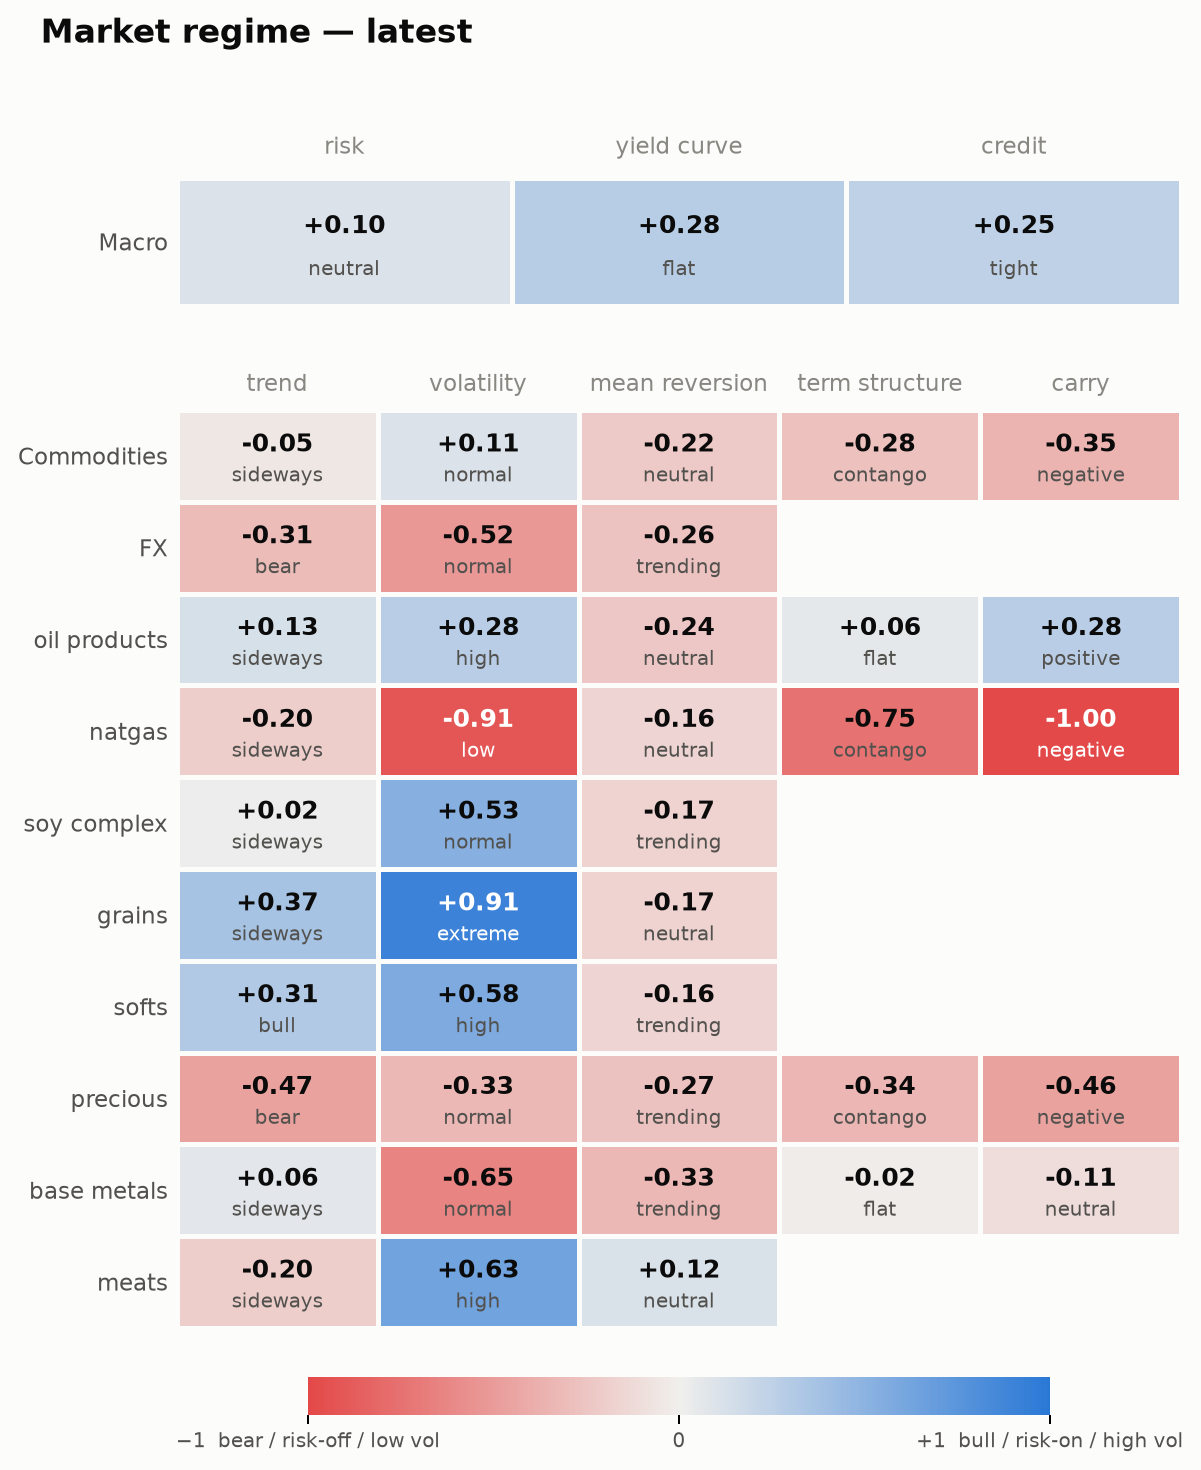

In [8]:
from IPython.display import Image, display

display(Image(filename=phase1["charts"]["snapshot"]))


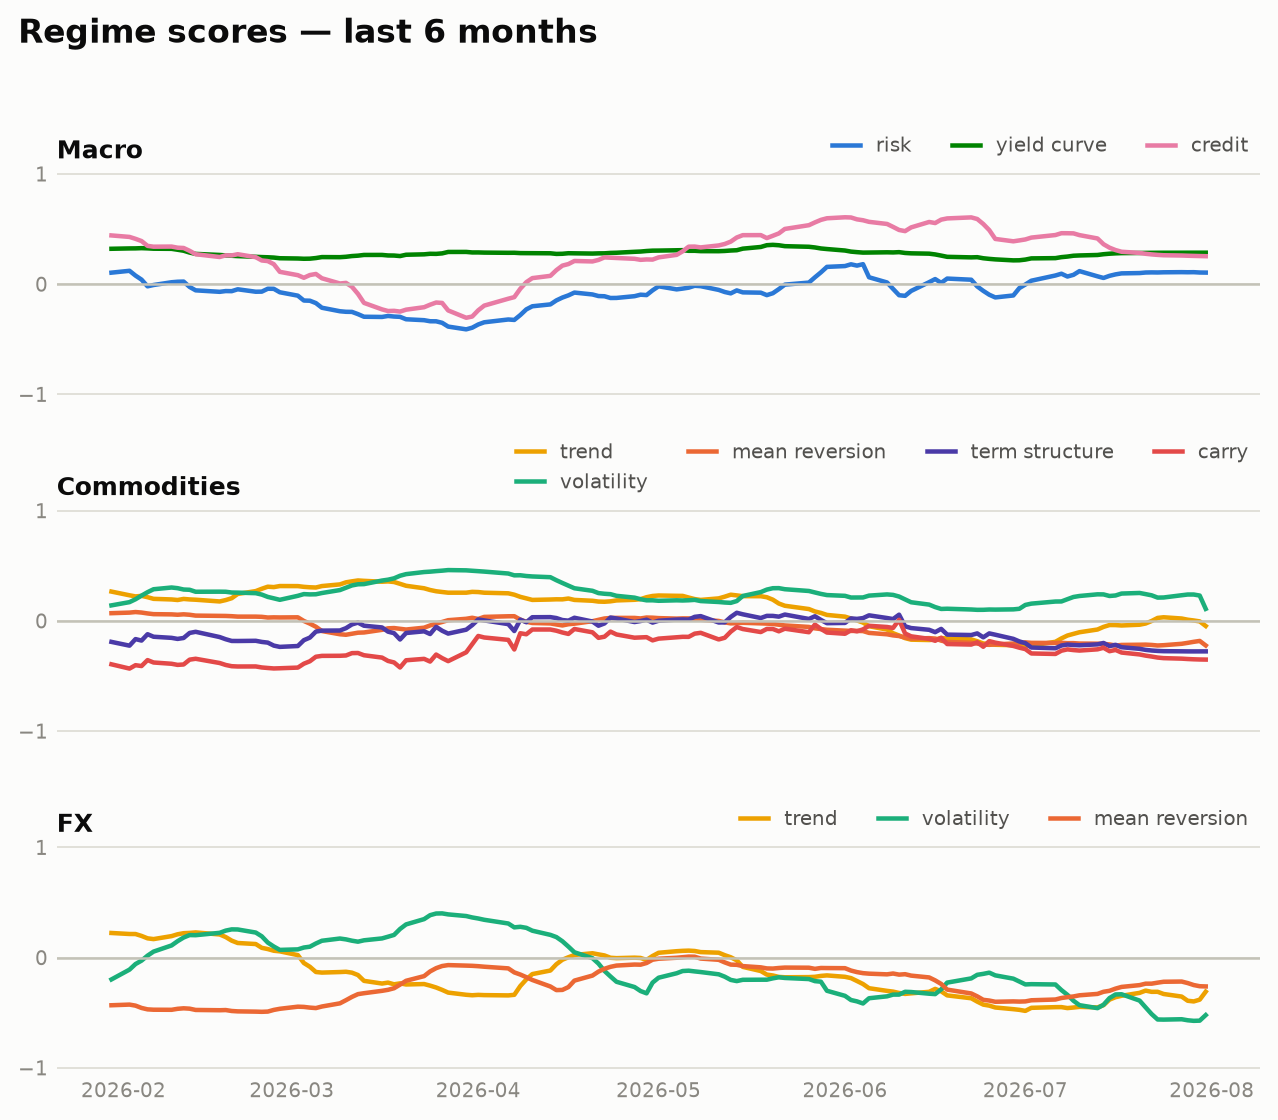

In [9]:
if phase1["charts"]["history"]:
    display(Image(filename=phase1["charts"]["history"]))


### Full-history label ribbon

One horizontal band per sector x dimension, coloured by which label was active, spanning the whole
sample, with the frozen episode table (grey shading) overlaid. First the sectors the episode table
actually names (legible at full width), then every sector.


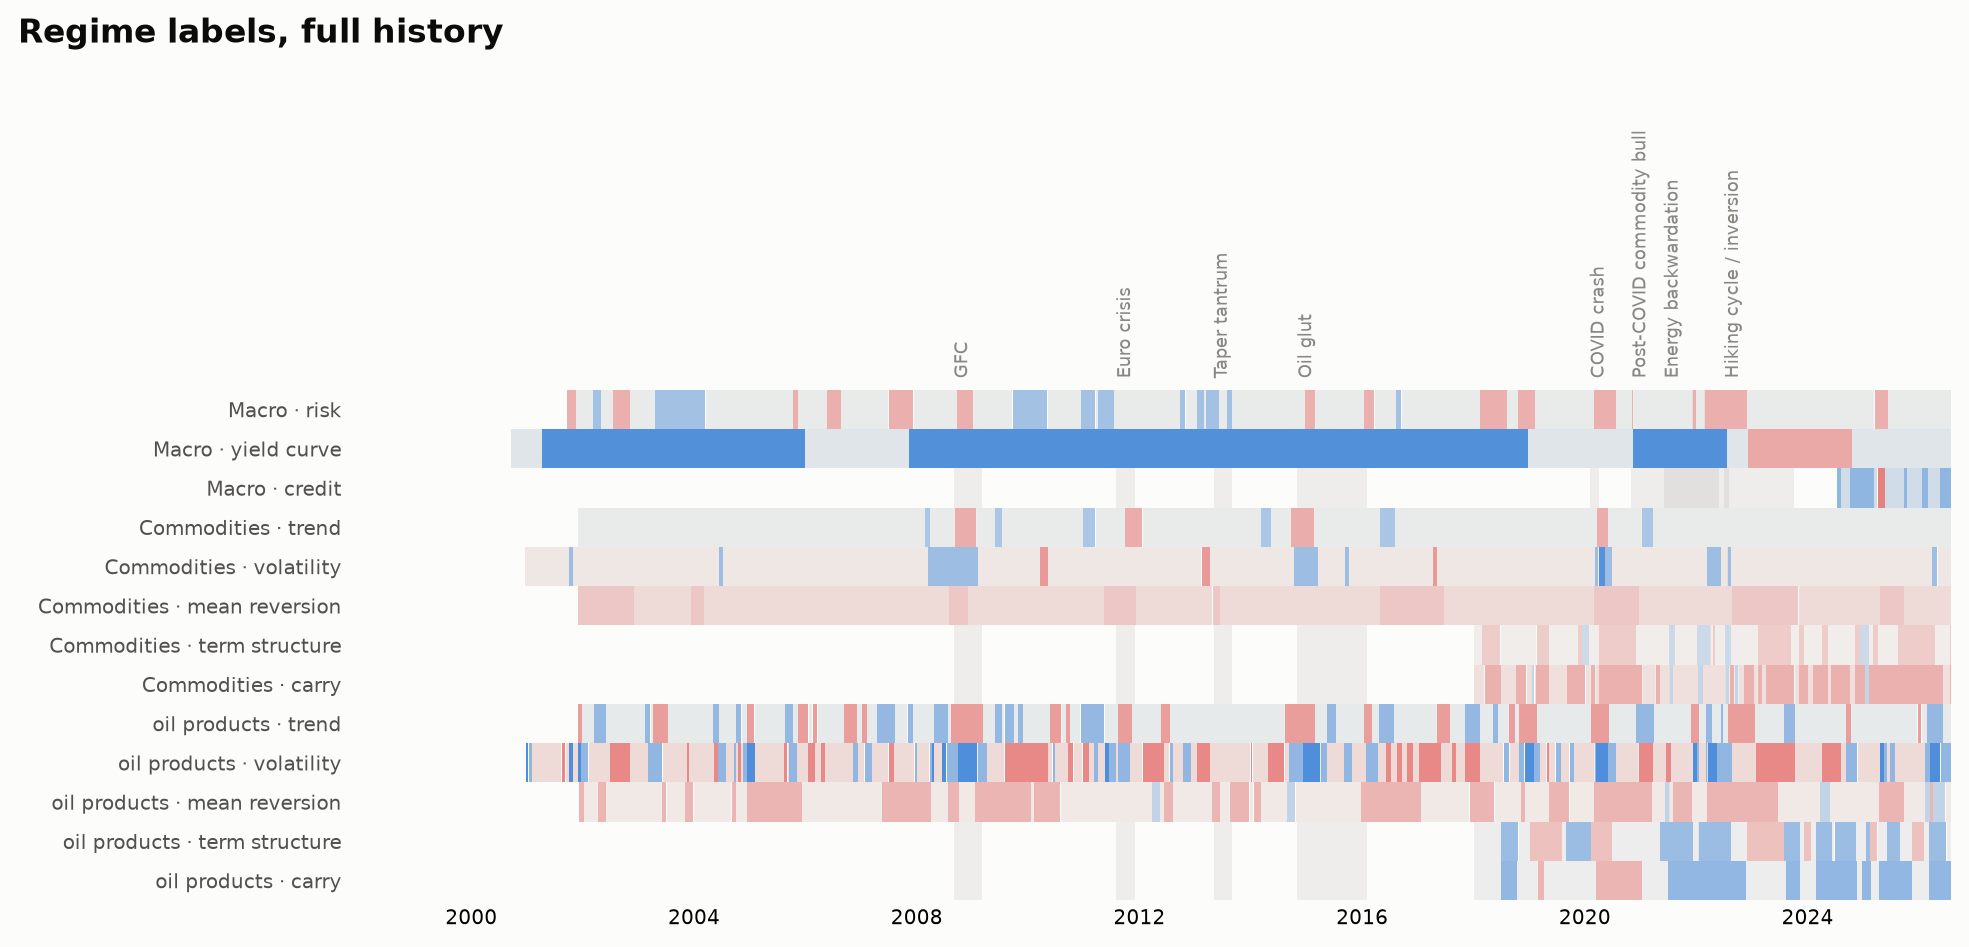

In [10]:
display(Image(filename=phase1["charts"]["ribbon_episode_sectors"]))


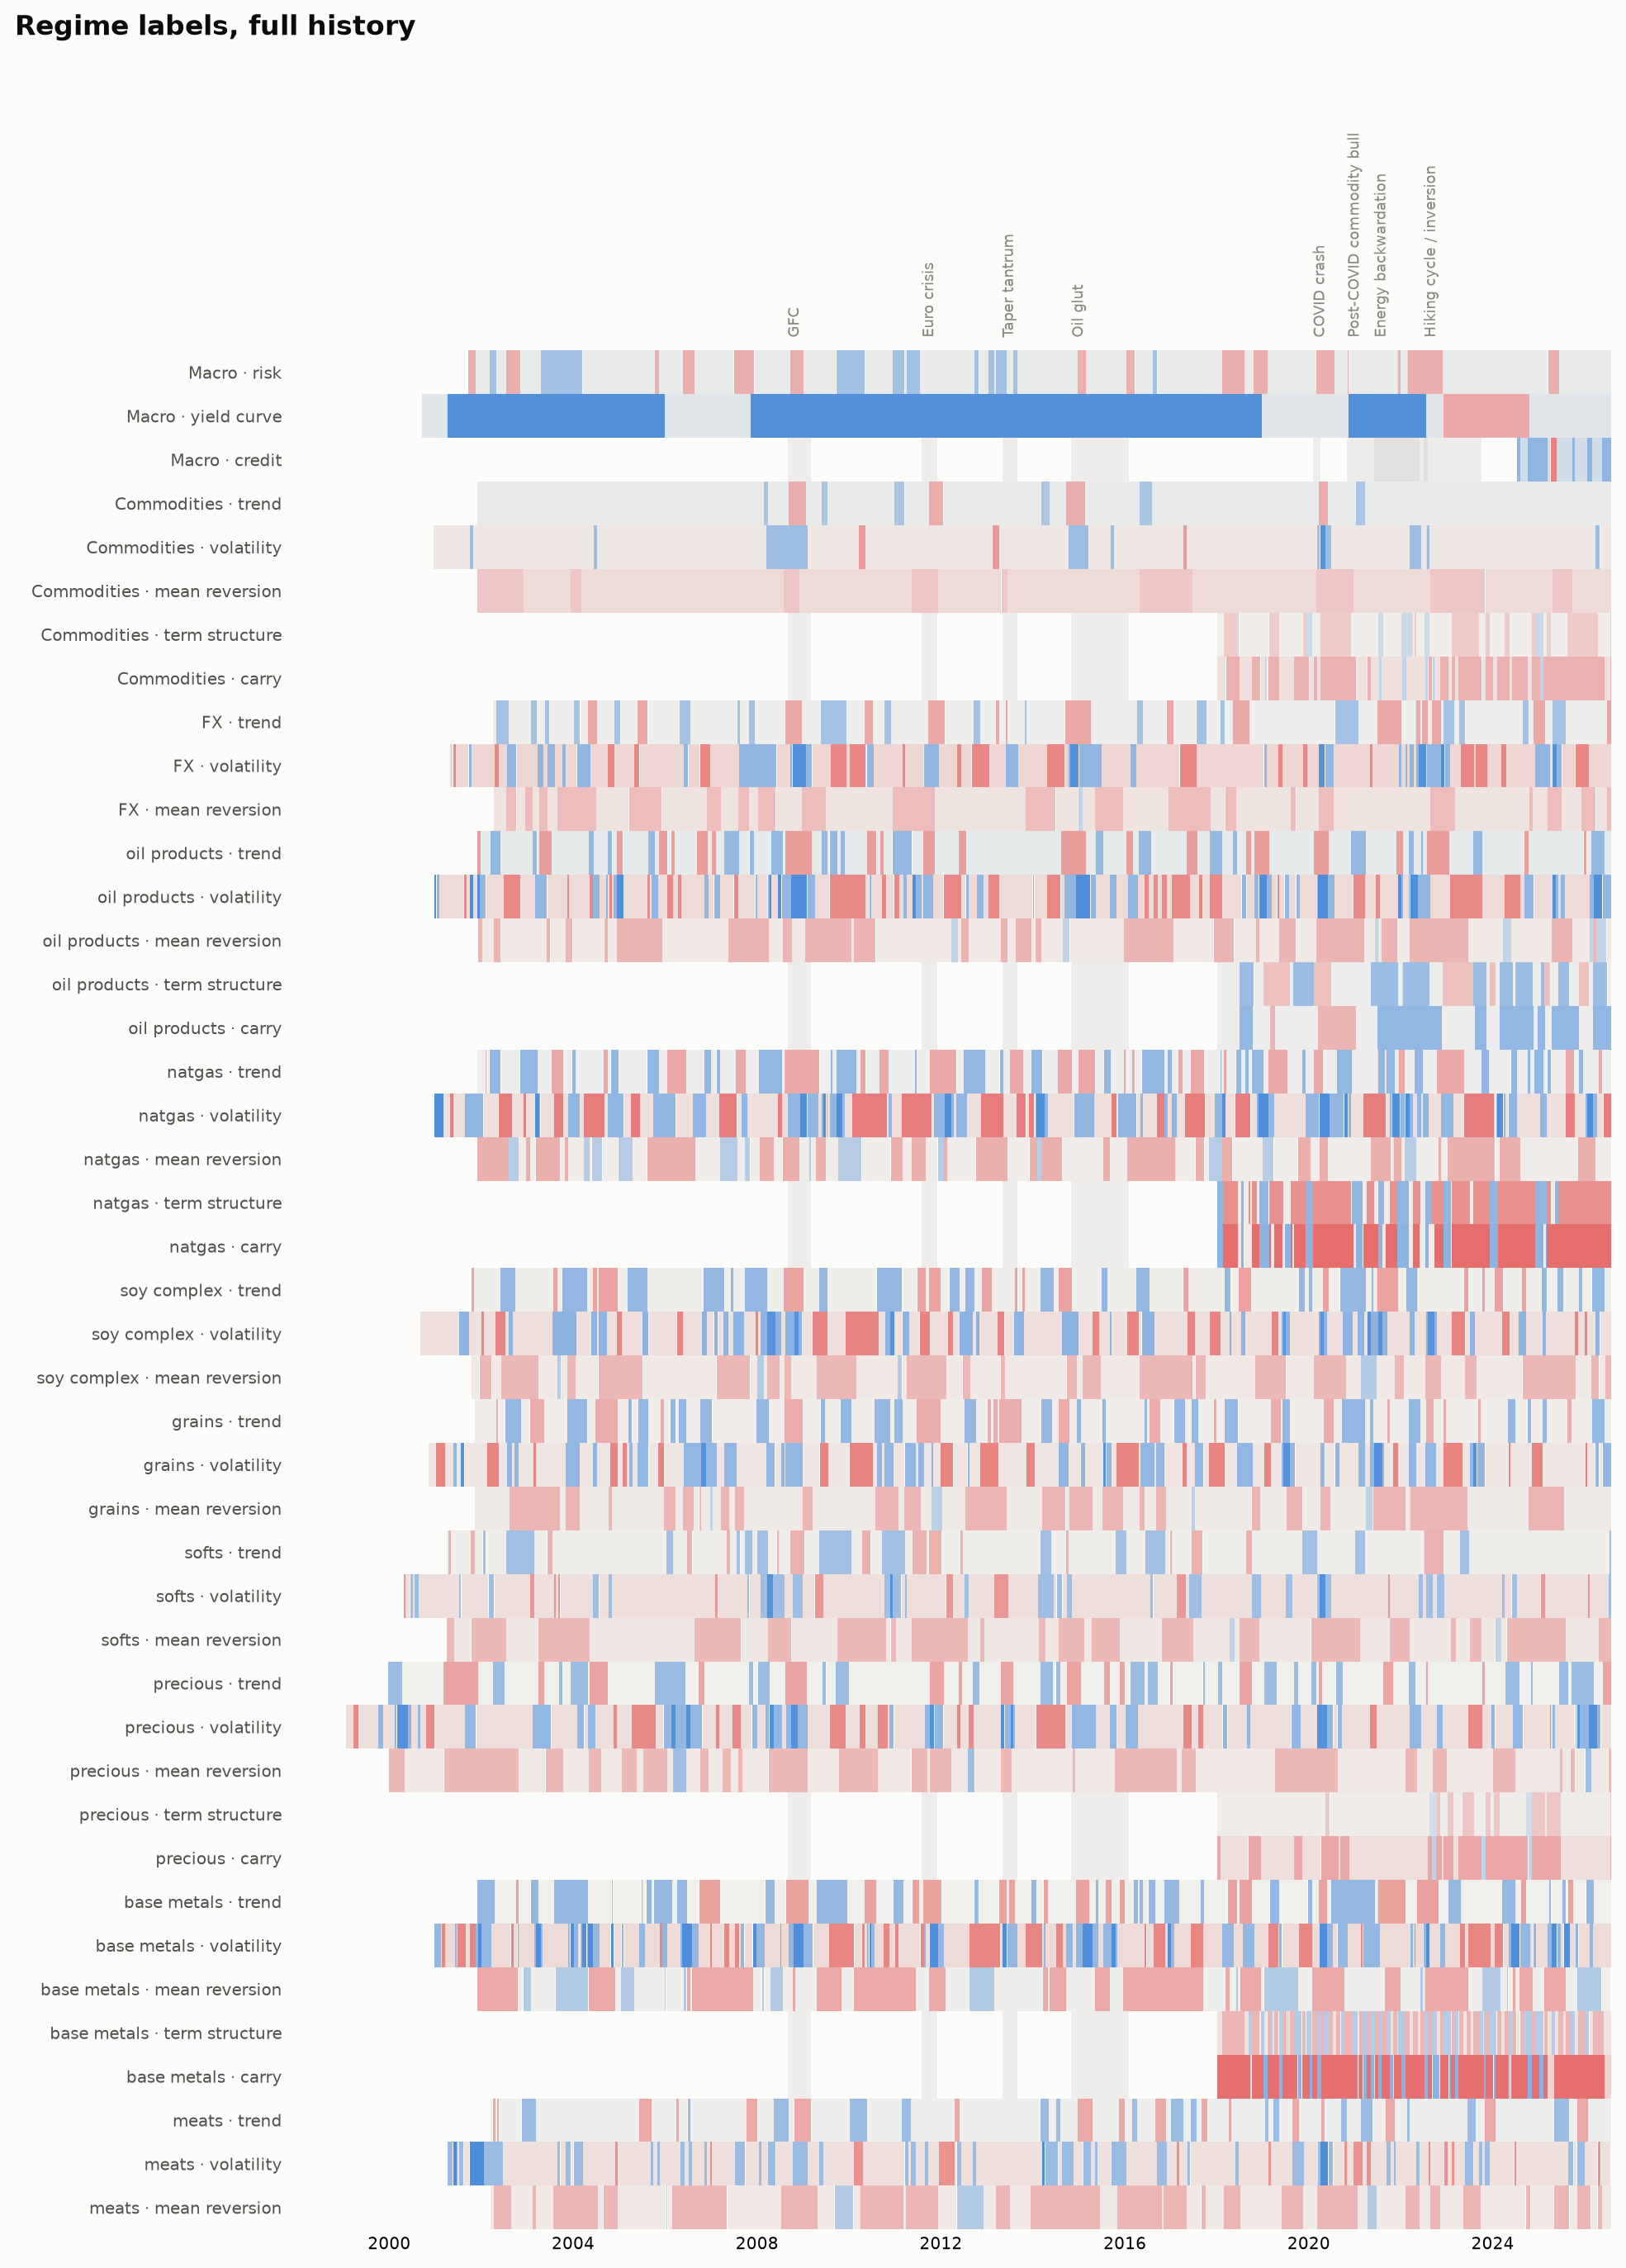

In [11]:
display(Image(filename=phase1["charts"]["ribbon_full"]))


## Phase 2 — Descriptive: does it behave like a regime model at all?

Per sector x dimension: transition matrix, regime durations, `label_stability` (flip rate, average
spell, labelled coverage), `expected_remaining_duration`. Three failure modes were named in advance
(NEXT_PROMPT.md sec6 Phase 2) and checked mechanically here, not by eye: >90% single-label
occupancy, a flip rate high enough that hysteresis isn't binding, and a dimension NaN for most of
the sample. Any dimension tripping one of these is disqualified from Phase 3 scoring.


In [12]:
phase2 = load("phase_2_14_results.json")
stats = pd.DataFrame(phase2["per_sector_dimension"])
stats[
    ["sector", "dimension", "n_bars", "pct_of_sector_history_covered", "flip_rate", "avg_duration",
     "max_single_label_occupancy", "disqualified"]
].sort_values(["sector", "dimension"])


,sector,dimension,n_bars,pct_of_sector_history_covered,flip_rate,avg_duration,max_single_label_occupancy,disqualified
3,Commodities,carry,2157,0.297640,0.019017,51.357143,0.602225,False
4,Commodities,mean_reversion,6195,0.854836,0.002745,344.166667,0.760452,False
5,Commodities,term_structure,2157,0.297640,0.014378,67.406250,0.566991,False
6,Commodities,trend,6196,0.854974,0.003228,295.047619,0.902356,True
7,Commodities,volatility,6430,0.887264,0.004044,238.148148,0.894557,False
8,FX,mean_reversion,6144,0.936300,0.007000,139.636364,0.638346,False
9,FX,trend,6145,0.936452,0.011556,85.347222,0.684133,False
10,FX,volatility,6379,0.972112,0.014425,68.591398,0.621100,False
2,Macro,credit,516,0.079008,0.019417,46.909091,0.515504,True
0,Macro,risk,6280,0.961568,0.007804,125.600000,0.715127,False


In [13]:
print(f"{len(phase2['disqualified'])} sector x dimension pairs disqualified from Phase 3:")
for item in phase2["disqualified"]:
    print(f"  {item['sector']} / {item['dimension']}: {item['reasons']}")


2 sector x dimension pairs disqualified from Phase 3:
  Macro / credit: ['labelled coverage 7.90% of sector history < 10%']
  Commodities / trend: ['single-label occupancy 90.24% > 90%']


`Macro / credit` (7.9% coverage) is a real, previously-undisclosed data gap surfaced here, not in
Phase 0: `BAMLH0A0HYM2`/`BAMLC0A0CM` (the two credit-spread FRED series) only start 2023-07-17 in
this repo's cache, 33 years later than `VIXCLS`/`T10Y2Y`. `Commodities / trend` fails the occupancy
check at 90.24% -- essentially always "sideways" for a 20-symbol pooled basket, i.e. no single trend
regime dominates a diversified commodity book long enough to move the aggregate score outside the
sideways band. Both are excluded from every Phase 3 comparison below.


## Phase 3 — Accuracy against independently-known regime periods

Two ground-truth sources, both frozen in Phase 0: (a) the hand-labelled episode table, scored as
balanced accuracy of the engine's causal label against three baselines (persistence, one-step
Markov, expanding class-prior, all reusing the already-ported `regime.prediction` functions) within
each episode's date window; (b) mechanical, forward-realized-quantity labels (vol terciles, sign of
forward return, sign of `T10Y2Y`, sign of the f1-f2 curve spread) scored the same way over the whole
available history. Both holdouts are untouched: every series is truncated to dates before
2025-01-01 before any target or baseline is built.


In [14]:
phase3 = load("phase_3_14_results.json")
print("n_trials:", phase3["n_trials"])
print("Excluded (disqualified in Phase 2):", phase3["disqualified_excluded"])


n_trials: {'episode_table': 14, 'mechanical_labels': 25, 'total': 39}
Excluded (disqualified in Phase 2): ['Commodities|trend', 'Macro|credit']


### (a) Episode table


In [15]:
rows = []
for key, v in phase3["episode_table"]["per_sector_dimension"].items():
    if v.get("excluded"):
        rows.append({"sector_dimension": key, "n_obs": None, "balanced_accuracy": None,
                      "vs_best_baseline": v["reason"]})
        continue
    vb = v.get("vs_best_baseline", {})
    rows.append({
        "sector_dimension": key,
        "n_obs": v["n_obs"],
        "balanced_accuracy": round(v["engine"]["balanced_accuracy"], 3),
        "vs_best_baseline": f"{vb.get('baseline')} diff={vb.get('mean_hit_rate_diff'):+.4f} p={vb.get('pvalue'):.4f}" if vb else None,
    })
pd.DataFrame(rows)


,sector_dimension,n_obs,balanced_accuracy,vs_best_baseline
0,Macro|risk,567.0,0.353,persistence diff=+0.0000 p=1.0000
1,Macro|credit,NaN,NaN,disqualified in Phase 2
2,Macro|yield_curve,400.0,0.825,persistence diff=+0.0025 p=0.5260
3,Commodities|trend,NaN,NaN,disqualified in Phase 2
4,oil products|term_structure,295.0,0.919,persistence diff=+0.0000 p=1.0000
5,Commodities|volatility,42.0,0.048,markov diff=+0.0000 p=1.0000
6,FX|volatility,42.0,0.238,markov diff=+0.0000 p=1.0000
7,oil products|volatility,42.0,0.286,markov diff=+0.0000 p=1.0000
8,natgas|volatility,42.0,0.167,markov diff=+0.0000 p=1.0000
9,soy complex|volatility,42.0,0.000,persistence diff=+0.0000 p=1.0000


**A structural caveat, discovered here rather than assumed in advance:** within a single named
episode's short window, the engine's own flip rate is low (Phase 2), so the persistence and
one-step-Markov baselines are very often *literally identical* to the engine's own label that day --
they inherit whatever the engine said yesterday, which is usually what it says today too. That
makes "engine vs. persistence/Markov" comparisons within episode windows structurally weak evidence
either way. The class-prior baseline has the opposite problem: episodes are chosen because they are
historically unusual, so the sector/dimension's *modal* label over its whole history is almost never
the episode's expected label, guaranteeing class-prior scores near zero regardless of whether the
engine is any good. Neither baseline comparison is very informative for source (a) alone; the
mechanical-label comparisons in (b) below, with much larger `n_obs` and less structural dependence on
the same short window, carry the real evidentiary weight.


In [16]:
lags = phase3["episode_table"]["lead_lag_days"]
import numpy as np
print(f"Lead-lag across {len(lags)} scored episode/dimension pairs (trading days, negative = early):")
print(sorted(round(l) for l in lags))
print(f"Median: {np.median(lags):.1f} trading days")


Lead-lag across 14 scored episode/dimension pairs (trading days, negative = early):
[-21, -21, -18, 15, 20, 20, 24, 30, 32, 35, 37, 37, 40, 110]
Median: 27.0 trading days


### (b) Mechanical labels


In [17]:
rows = []
for key, v in phase3["mechanical_labels"].items():
    if v.get("insufficient_data"):
        continue
    vb = v.get("vs_best_baseline", {})
    rows.append({
        "sector_dimension_check": key,
        "n_obs": v["n_obs"],
        "balanced_accuracy": round(v["engine"]["balanced_accuracy"], 3),
        "hit_rate": round(v["engine"]["hit_rate"], 3),
        "vs_best_baseline": f"{vb.get('baseline')} diff={vb.get('mean_hit_rate_diff'):+.4f} p={vb.get('pvalue'):.4f}" if vb else None,
    })
pd.DataFrame(rows).sort_values("balanced_accuracy", ascending=False)


,sector_dimension_check,n_obs,balanced_accuracy,hit_rate,vs_best_baseline
19,Macro|yield_curve|contemporaneous_T10Y2Y_sign,4889,0.981,0.991,persistence diff=+0.0000 p=1.0000
21,oil products|term_structure|contemporaneous_f1...,1180,0.879,0.886,persistence diff=+0.0017 p=0.2340
22,natgas|term_structure|contemporaneous_f1f2_spr...,1513,0.871,0.892,markov diff=+0.0000 p=1.0000
20,Commodities|term_structure|contemporaneous_f1f...,720,0.679,0.665,markov diff=+0.0000 p=1.0000
3,natgas|volatility|forward_21d_vol_tercile,6012,0.657,0.691,markov diff=+0.0000 p=1.0000
7,precious|volatility|forward_21d_vol_tercile,6084,0.640,0.709,markov diff=+0.0000 p=1.0000
4,soy complex|volatility|forward_21d_vol_tercile,6043,0.639,0.705,markov diff=+0.0002 p=0.2860
24,base metals|term_structure|contemporaneous_f1f...,1501,0.631,0.633,markov diff=+0.0000 p=1.0000
2,oil products|volatility|forward_21d_vol_tercile,5986,0.630,0.702,markov diff=+0.0000 p=1.0000
1,FX|volatility|forward_21d_vol_tercile,5960,0.617,0.703,markov diff=+0.0000 p=1.0000


`Macro / yield_curve` vs. contemporaneous `T10Y2Y` sign (98.1% balanced accuracy) and
`.../term_structure` vs. the f1-f2 spread sign (87-89% for oil products/natgas) are close to
tautological rather than independent confirmations: `macro.yield_curve` is built directly from
`T10Y2Y` (50% of its weight), and `ts.curve_slope` *is* a transform of the f1-f2 spread. High
accuracy there mostly validates the scoring/banding arithmetic, not the regime concept. `trend` vs.
the sign of the forward 63-day return is the genuinely independent test, and it is weak-to-null
across every basket (balanced accuracy 0.39-0.60, i.e. coin-flip to worse-than-coin-flip) --
consistent with this programme's twenty-two-plus prior null findings on trend-following edge.


## Phase 4 — Pre-registered gates

Unlike every alpha-gate notebook before this one, **a gate firing (passing) is the desired
outcome** here -- the engine already ships every morning in production, so a null means production
has been shipping noise. Reported without hedging, whichever way it lands. RA/RM apply Bonferroni
correction across `n_trials=39` (14 episode-table + 25 mechanical-label sector/dimension pairs).


In [18]:
phase4 = load("phase_4_14_results.json")
for gate_id, g in phase4.items():
    status = "FIRES" if g["fires"] else "null"
    print(f"{gate_id:3s} [{status:5s}] {g['claim']}")


NL  [FIRES] no_lookahead_check passes at every truncation for every sector
RA  [null ] Balanced accuracy on the episode table significantly beats the class-prior baseline
RM  [null ] Balanced accuracy on mechanical labels significantly beats persistence and Markov baselines
RL  [null ] Median label lag at episode onset <= 21 trading days
RS  [FIRES] No scored dimension exceeds 90% single-label occupancy or flips more than once per 10 bars
RC  [FIRES] Port fidelity: ported engine matches source scores where checkable


## Phase 5 — Verdict and handoff

**NL and RC fire**: the port is faithful (bit-identical to the source engine on synthetic fixtures,
config hashes match, `no_lookahead_check` passes on real data at every truncation for all 27
symbols) and structurally sound (no lookahead anywhere in the pipeline). **RS fires**: excluding the
two Phase-2-disqualified dimensions, nothing scored is degenerate (single-label-stuck or flip-noise).

**RA, RM, and RL do not fire.** No sector/dimension pair beats its baselines at a Bonferroni-corrected
significance level, in either ground-truth source. Median label lag at episode onset was 27 trading
days, worse than the 21-day pre-registered threshold. Read together with Phase 3's numbers, the
honest per-dimension picture is:

- **`term_structure` and `carry` (oil products, natgas)**: highest raw accuracy (85-93%), but the
  mechanical check that produced the higher numbers is close to tautological (the indicator *is* a
  transform of the same spread the check compares against). Not independent confirmation.
- **`yield_curve` (Macro)**: similarly high but similarly tautological (built from `T10Y2Y`, checked
  against `T10Y2Y`'s own sign).
- **`trend` (every basket)**: weak-to-null against forward 63-day returns (0.39-0.60 balanced
  accuracy) -- consistent with this programme's prior findings that trend-following lacks
  demonstrated edge here.
- **`risk` (Macro)**: 35.3% accuracy against four named crisis episodes' `risk_off` label -- worse
  than chance for what is nominally a three-state classifier. The engine largely failed to identify
  three of four historical crises as risk-off.
- **`volatility` (every basket) during COVID**: mostly failed to reach "extreme" during the
  2020-02-01 to 2020-04-01 window (several sectors scored 0.0-0.29 balanced accuracy against the
  episode table), though the broader mechanical vol-tercile check (much larger sample) shows more
  reasonable 0.54-0.66 balanced accuracy outside that one acute episode.
- **`Macro / credit` and `Commodities / trend`**: disqualified in Phase 2 (a real 2023-only FRED
  data gap, and near-total single-label occupancy respectively) -- not scored at all, not
  trustworthy by construction.

**No dimension here is validated strongly enough, independent of near-tautological mechanical
checks, for a follow-up notebook to condition a strategy on it without further work.** The two
highest-accuracy dimensions (`term_structure`/`carry`, `yield_curve`) would need an independent
(non-tautological) mechanical check before that changes. `trend` and `risk` look actively unreliable
during named crisis/trend episodes on this data. This notebook authorizes no trading and spends no
holdout -- both remain untouched (crypto 2025-07-01, futures 2025-01-01 -> 2026-07-28) for whatever
comes next.
